## Section 1 — Data Loading

CO (L2 swath), AER_AI (L2 swath), fire centre from MODIS FRP CSV.
0.25° grid; AI > 2.0 plume mask; northern artefacts clipped above row 160.


In [1]:
%cd ..
from pathlib import Path
import sys, warnings, traceback

import glob
import h5py
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree
import netCDF4 as nc4

ROOT = Path(".").resolve()

/Users/maperezc/Downloads/wildfires


In [2]:
# ── Case study parameters ──────────────────────────────────────────────────
DATA_DIR = ROOT / "data"

# Date — NOTE: mmdd column in hotspot CSV is int64 (118, not "0118")
FIRE_DATE: str = "2026-01-18"
TARGET_DAY: str    = "".join(FIRE_DATE.split("-")[1:])   # "0118"

# ── L2 file paths (structure verified in docs/l2_file_structure_jan18.txt) ─
CO_L2_PATTERN   = DATA_DIR / TARGET_DAY / "S5P_OFFL_L2__CO_____*.nc"
AER_LH_L2_PATTERN = DATA_DIR / TARGET_DAY / "S5P_OFFL_L2__AER_LH_2026*"
AER_AI_L2_PATTERN = DATA_DIR / TARGET_DAY / "S5P_OFFL_L2__AER_AI_2026*"

CO_L2_PATH   = glob.glob(str(CO_L2_PATTERN))
AER_LH_L2_PATH = Path(glob.glob(str(AER_LH_L2_PATTERN))[0])
AER_AI_L2_PATH = Path(glob.glob(str(AER_AI_L2_PATTERN))[0])

# Paths
HOTSPOT_CSV:   Path = DATA_DIR  / "daily_dominant_hotspot_summary.csv"
ERA5_SFC_PATH: Path = DATA_DIR  / "ERA5_winds.nc"
ERA5_PL_PATH:  Path = DATA_DIR  / "ERA5_winds_pressure_levels.nc"
OUT_DIR:       Path = ROOT / "outputs" / "co_final" / TARGET_DAY
OUT_DIR.mkdir(parents=True, exist_ok=True)

QA_THRESH   = 0.5
AI_THRESHOLD = 2.0  # Consistent with hotspot_analysis.py (CLAUDE.md)
AER_LH_MIN_PIXELS  = 20  # Minimum valid AER_LH pixels for pressure selection
QA_UINT8: int          = int(QA_THRESH * 100)

In [3]:
# ── Physical constants ─────────────────────────────────────────────────────
CO_MOLAR_MASS_KG_PER_MOL = 0.02801   # kg mol⁻¹
EARTH_RADIUS_KM = 6_371.0            # WGS-84 mean
M_PER_DEG_LAT = 111_320.0            # m deg⁻¹

BOX_FRACTION             = 0.20

GRID_SPACING_DEG: float = 0.25 # CHECK: 4 km from the paper

# Plume
ALH_RADIUS_KM:         float = 300.0
FALLBACK_PRESSURE_HPA: float = 800.0

# CSF
N_TRANSECTS:            int   = 10
TRANSECT_HALF_WIDTH_KM: float = 100.0   # matches csf_dynamic_wind.ipynb

# Change D background window — far-upwind scalar median
BG_X_MIN_KM: float = -300.0
BG_X_MAX_KM: float = -200.0

matplotlib.rcParams.update({"font.size": 10, "figure.dpi": 120})
print("ROOT:", ROOT)
print(f"N_TRANSECTS={N_TRANSECTS}, TRANSECT_HALF_WIDTH_KM={TRANSECT_HALF_WIDTH_KM}")

# Spatial domain
LAT_MIN: float = -66.83;  LAT_MAX: float = -6.83
LON_MIN: float = -103.05; LON_MAX: float = -43.05

ROOT: /Users/maperezc/Downloads/wildfires
N_TRANSECTS=10, TRANSECT_HALF_WIDTH_KM=100.0


In [4]:
from src.data_helpers import load_co_l2, load_aer_ai, load_aer_lh, get_modis_hotspot
from collections import defaultdict

chunks = defaultdict(list)
scalars = {}

for co_l2_pth in CO_L2_PATH:
    co_pth = Path(co_l2_pth)
    co_data = load_co_l2(
        co_pth,
        lat_min=LAT_MIN,
        lat_max=LAT_MAX,
        lon_min=LON_MIN,
        lon_max=LON_MAX,
        qa_threshold=QA_UINT8,
    )

    if co_data is None:
        continue  # skip orbits with no valid pixels in the ROI

    for k, v in co_data.items():
        if isinstance(v, np.ndarray):
            chunks[k].append(v)
        else:
            scalars[k] = v

co_data = {k: np.concatenate(v) for k, v in chunks.items()}
co_data.update(scalars)  # e.g. 'source': 'l2_swath'

ai_data = load_aer_ai(AER_AI_L2_PATH,
                lat_min = LAT_MIN,
                lat_max = LAT_MAX,
                lon_min = LON_MIN,
                lon_max = LON_MAX,
                qa_threshold = QA_UINT8)

alh_data = load_aer_lh(AER_LH_L2_PATH,
                lat_min = LAT_MIN,
                lat_max = LAT_MAX,
                lon_min = LON_MIN,
                lon_max = LON_MAX,
                qa_threshold = QA_UINT8)

modis = get_modis_hotspot(HOTSPOT_CSV,
                        FIRE_DATE,
                        lat_min = LAT_MIN,
                        lat_max = LAT_MAX,
                        lon_min = LON_MIN,
                        lon_max = LON_MAX,
                        )

FIRE_LAT, FIRE_LON = modis["dominant_lat"].values[0], modis["dominant_lon"].values[0]

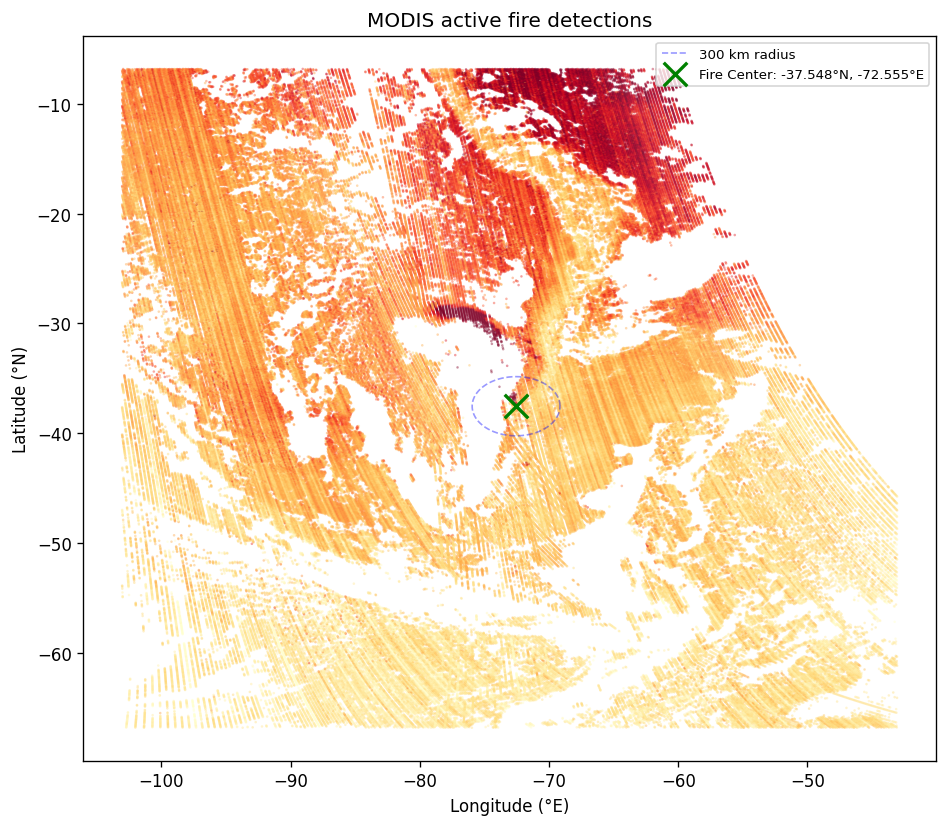

In [5]:
EXTRACTION_RADIUS_KM = 300

lat_domain = co_data["lat"]
lon_domain = co_data["lon"]
co_domain = co_data["co"]

# ── Map: MODIS detections coloured by cluster ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

# Background: scatter L2 domain pixels
# (minp, maxp defined in cell 4 from no2_domain)
_minp_bg = np.nanpercentile(co_domain[co_domain > 0] * 1e6, 1) if 'co_domain' in dir() else 0
_maxp_bg = np.nanpercentile(co_domain[co_domain > 0] * 1e6, 99) if 'co_domain' in dir() else 25
im = ax.scatter(lon_domain, lat_domain, c=co_domain * 1e6,
                vmin=_minp_bg, vmax=_maxp_bg, cmap="YlOrRd", alpha=0.4, s=0.3,
                rasterized=True)

# 20 km radius circle around Method B centroid
theta_c = np.linspace(0, 2*np.pi, EXTRACTION_RADIUS_KM)
r_lat = EXTRACTION_RADIUS_KM / (M_PER_DEG_LAT / 1000.0)
r_lon = EXTRACTION_RADIUS_KM / ((M_PER_DEG_LAT / 1000.0) * np.cos(np.radians(FIRE_LAT)))
ax.plot(FIRE_LON + r_lon * np.cos(theta_c),
        FIRE_LAT + r_lat * np.sin(theta_c),
        "b--", alpha=0.4, lw=1, label=f"{EXTRACTION_RADIUS_KM} km radius")

ax.scatter(FIRE_LON, FIRE_LAT, marker="x", s=200, c="green",
           linewidths=2, label=f"Fire Center: {FIRE_LAT:.3f}°N, {FIRE_LON:.3f}°E")

ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
ax.set_title(f"MODIS active fire detections")
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig(OUT_DIR / "eda_s2_modis_clustering.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Section 2 — Wind Inputs

ERA5 10 m surface wind (regridded to TROPOMI grid).
AER_LH injection pressure: QA ≥ 0.5, haversine ≤ 300 km, KD-tree match to AER_AI plume, median aggregation.
ERA5 pressure-level wind (log-pressure interpolated to injection pressure).
Solar overpass formula: `OVERPASS_UTC = 13.0 − FIRE_LON/15.0`.


In [6]:
def bin_flat_to_grid(co_flat, co_lat, co_lon, ai_flat, ai_lat, ai_lon,
                     lat_min, lat_max, lon_min, lon_max, grid_deg):
    lat_edges = np.arange(lat_min, lat_max + grid_deg, grid_deg)
    lon_edges = np.arange(lon_min, lon_max + grid_deg, grid_deg)
    lat_c = (0.5 * (lat_edges[:-1] + lat_edges[1:])).astype(np.float32)
    lon_c = (0.5 * (lon_edges[:-1] + lon_edges[1:])).astype(np.float32)
    nlat, nlon = len(lat_c), len(lon_c)

    def _nanmean_bin(vals, lats, lons):
        grid = np.full((nlat, nlon), np.nan, dtype=np.float32)
        il = np.searchsorted(lat_edges[1:-1], lats)
        jl = np.searchsorted(lon_edges[1:-1], lons)
        ok = (il >= 0) & (il < nlat) & (jl >= 0) & (jl < nlon) & np.isfinite(vals)
        df = pd.DataFrame({"v": vals[ok].astype(float), "i": il[ok], "j": jl[ok]})
        for (i, j), v in df.groupby(["i", "j"])["v"].mean().items():
            grid[i, j] = float(v)
        return grid

    co_g  = _nanmean_bin(co_flat, co_lat, co_lon)
    ai_g  = _nanmean_bin(ai_flat.astype(np.float32), ai_lat, ai_lon)
    plume = (ai_g > AI_THRESHOLD) & np.isfinite(co_g)
    return lat_c, lon_c, co_g, ai_g, plume

# ── Build 0.25 deg grid ────────────────────────────────────────────────────────
lat, lon, co, ai, plume_raw = bin_flat_to_grid(
    co_data["co"], co_data["lat"], co_data["lon"],
    ai_data["ai"], ai_data["lat"], ai_data["lon"],
    LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, GRID_SPACING_DEG,
)
plume = plume_raw.copy()
plume[160:, :] = False   # clip northern artefacts (same as csf_dynamic_wind.ipynb)

assert np.isfinite(co).any(), "All CO grid cells are NaN."
assert plume.any(), f"No plume pixels at AI > {AI_THRESHOLD}."

print(f"Fire centre   : ({FIRE_LAT:.4f}N, {FIRE_LON:.4f}E)")
print(f"CO source     : {co_data['source']}  ({len(co_data['co']):,} flat pixels)")
print(f"Grid          : {co.shape},  CO cells={int(np.isfinite(co).sum()):,}")
print(f"Plume pixels  : {int(plume_raw.sum())} total -> {int(plume.sum())} after northern clip")
print(f"CO range      : [{float(np.nanmin(co))*1e3:.2f}, {float(np.nanmax(co))*1e3:.2f}] mmol/m2")

Fire centre   : (-37.5484N, -72.5545E)
CO source     : l2_swath  (255,784 flat pixels)
Grid          : (240, 240),  CO cells=37,070
Plume pixels  : 118 total -> 99 after northern clip
CO range      : [0.47, 198.24] mmol/m2


In [7]:
# ── Solar-time overpass — same formula for both surface and pressure-level wind ─
overpass_utc_h = 13.0 - FIRE_LON / 15.0
OVERPASS_UTC = pd.Timestamp(FIRE_DATE) + pd.Timedelta(hours=overpass_utc_h)
print(f"Overpass UTC: {OVERPASS_UTC}  (solar-time formula: 13.0 − {FIRE_LON}/15 = {overpass_utc_h:.2f} h)")

# ── ERA5 10m surface wind ──────────────────────────────────────────────────────
with xr.open_dataset(ERA5_SFC_PATH) as ds:
    td_sfc   = "valid_time" if "valid_time" in ds.dims else "time"
    dst      = ds.sel({td_sfc: OVERPASS_UTC}, method="nearest")
    era5_sfc_lat = dst["latitude"].values    # descending
    era5_sfc_lon = dst["longitude"].values
    u10_raw  = dst["u10"].values
    v10_raw  = dst["v10"].values
    _sel_t_sfc = dst[td_sfc].values
print(f"ERA5 surface: selected time = {_sel_t_sfc}")

def _regrid_era5(u_raw, v_raw, src_lat, src_lon, tgt_lat, tgt_lon):
    u_fn = RegularGridInterpolator(
        (src_lat[::-1], src_lon), u_raw[::-1],
        method="linear", bounds_error=False, fill_value=np.nan)
    v_fn = RegularGridInterpolator(
        (src_lat[::-1], src_lon), v_raw[::-1],
        method="linear", bounds_error=False, fill_value=np.nan)
    lo_g, la_g = np.meshgrid(tgt_lon, tgt_lat)
    pts = np.column_stack([la_g.ravel(), lo_g.ravel()])
    return (u_fn(pts).reshape(len(tgt_lat), len(tgt_lon)).astype(np.float32),
            v_fn(pts).reshape(len(tgt_lat), len(tgt_lon)).astype(np.float32))

u10, v10 = _regrid_era5(u10_raw, v10_raw, era5_sfc_lat, era5_sfc_lon, lat, lon)

_pw = plume & np.isfinite(u10)
assert _pw.any(), "No plume pixels with valid ERA5 10m wind."
u_sfc     = float(u10[_pw].mean())
v_sfc     = float(v10[_pw].mean())
spd_sfc   = float(np.hypot(u_sfc, v_sfc))
theta_sfc = float(np.arctan2(v_sfc, u_sfc))
print(f"ERA5 10m plume-mean: u={u_sfc:.3f}, v={v_sfc:.3f} -> {spd_sfc:.3f} m/s  "
      f"(theta={np.degrees(theta_sfc):.1f} deg CCW East)")

Overpass UTC: 2026-01-18 17:50:13.080000  (solar-time formula: 13.0 − -72.5545/15 = 17.84 h)
ERA5 surface: selected time = 2026-01-18T18:00:00.000000000
ERA5 10m plume-mean: u=0.236, v=8.716 -> 8.719 m/s  (theta=88.5 deg CCW East)


In [8]:
from src.wind_helpers import select_injection_pressure

psel = select_injection_pressure(
    ai_raw=ai_data["ai"],
    ai_lat=ai_data["lat"],
    ai_lon=ai_data["lon"],
    alh_pres_raw=alh_data["alh_pres"],
    alh_lat=alh_data["lat"],
    alh_lon=alh_data["lon"],
    fire_lat=FIRE_LAT,
    fire_lon=FIRE_LON,
    ai_threshold=AI_THRESHOLD,
    radius_km=EXTRACTION_RADIUS_KM,
    min_pixels=AER_LH_MIN_PIXELS,
    aggregation="median",
)

injection_pressure_hpa = psel["injection_pressure_hpa"]
p_alh_hpa              = injection_pressure_hpa
print(f"Selected injection pressure: {injection_pressure_hpa:.0f} hPa  [{psel['pressure_source']}]")

[select_injection_pressure] AER_AI plume pixels (AI > 2.0): 3162
[select_injection_pressure] AER_LH pixels within 300 km of fire: 2431
[select_injection_pressure] AER_LH pixels matched to AI plume: 97
[select_injection_pressure] Pressure stats: median=891 hPa, max=988 hPa, IQR=131 hPa
Selected injection pressure: 891 hPa  [aer_ai_plume_median (n=97, r=300km)]


/Users/maperezc/Downloads/wildfires/src/wind_helpers.py:185: UserWarning: Pressure IQR = 131 hPa > 100 hPa. The plume is vertically complex; a single injection pressure level is a poor approximation.
  warnings.warn(


In [9]:
era5 = xr.open_dataset(ERA5_PL_PATH)
time_dim = "valid_time" if "valid_time" in era5.dims else "time"
era5_t = era5.sel({time_dim: OVERPASS_UTC}, method="nearest")

# Nearest ERA5 grid point to fire centre
era5_lat_key = "latitude" if "latitude" in era5_t.coords else "lat"
era5_lon_key = "longitude" if "longitude" in era5_t.coords else "lon"
era5_lats = era5_t[era5_lat_key].values
era5_lons = era5_t[era5_lon_key].values

i_lat = int(np.argmin(np.abs(era5_lats - FIRE_LAT)))
i_lon = int(np.argmin(np.abs(era5_lons - FIRE_LON)))

u_profile = era5_t["u"].isel(**{era5_lat_key: i_lat, era5_lon_key: i_lon}).values.ravel()
v_profile = era5_t["v"].isel(**{era5_lat_key: i_lat, era5_lon_key: i_lon}).values.ravel()
p_levels  = era5_t["pressure_level"].values.ravel()  # hPa, descending

print(f"ERA5 grid point: {era5_lats[i_lat]:.2f}°N, {era5_lons[i_lon]:.2f}°E")
print(f"Pressure levels: {p_levels.min():.0f}–{p_levels.max():.0f} hPa ({len(p_levels)} levels)")

# ── Log-pressure interpolation ────────────────────────────────────────
sort_idx  = np.argsort(p_levels)   # ascending pressure order
p_sorted  = p_levels[sort_idx]
u_sorted  = u_profile[sort_idx]
v_sorted  = v_profile[sort_idx]

def interp_log_p(p_target_hpa, p_sorted, u_sorted, v_sorted):
    'Log-pressure interpolation for a single target level.'
    log_p = np.log(p_sorted)
    u_i = float(np.interp(np.log(p_target_hpa), log_p, u_sorted))
    v_i = float(np.interp(np.log(p_target_hpa), log_p, v_sorted))
    return u_i, v_i

# ── Extract wind at injection pressure (set in Section 3a) ───────────
# injection_pressure_hpa is defined in the AER_AI/AER_LH cell that
# precedes this in execution order (Section 3a, inserted before Section 3).
# If that cell has not run yet, fall back to 900 hPa.
_p_extract = injection_pressure_hpa if "injection_pressure_hpa" in dir() else 900.0
u_alh, v_alh = interp_log_p(_p_extract, p_sorted, u_sorted, v_sorted)
spd_alh = float(np.hypot(u_alh, v_alh))
theta_alh  = float(np.arctan2(v_alh, u_alh))
WIND_SOURCE = pressure_source if "pressure_source" in dir() else f"ERA5 {_p_extract:.0f} hPa"

print(f"\nWind at {_p_extract:.0f} hPa ({WIND_SOURCE}):")
print(f"  U={u_alh:+.2f}, V={v_alh:+.2f} m/s, speed={spd_alh:.2f} m/s, "
      f"θ={np.degrees(theta_alh):.1f}°")

# Uniform wind fields for compute_csf_dynamic
u_alh_field = np.full_like(u10, u_alh)
v_alh_field = np.full_like(v10, v_alh)

ERA5 grid point: -37.50°N, -72.50°E
Pressure levels: 125–975 hPa (13 levels)

Wind at 891 hPa (ERA5 891 hPa):
  U=-3.82, V=+8.02 m/s, speed=8.88 m/s, θ=115.5°


## Section 3 — Background Methods

**Change D** (primary): scalar median of CO pixels in x_rot ∈ [−300, −200] km.
**Box-fraction** (reference): `estimate_background(box_fraction=0.20)` from `co_csf_griffin_l2.ipynb`.

Both `co_delta` arrays are computed here and used in Section 4 to explain
the discrepancy with the prior notebook.


In [10]:
from src.csf_utils import (
estimate_background,
build_dynamic_transects,
compute_local_wind_direction,
compute_csf_dynamic
)

def _x_rot_km(lat_1d, lon_1d, theta_rad):
    """Project each grid cell onto the downwind axis (km). Negative = upwind."""
    lat_c = float(lat_1d.mean())
    lon_c = float(lon_1d.mean())
    lo_g, la_g = np.meshgrid(lon_1d, lat_1d)
    x_m = (lo_g - lon_c) * np.cos(np.radians(lat_c)) * M_PER_DEG_LAT
    y_m = (la_g - lat_c) * M_PER_DEG_LAT
    return (x_m * np.cos(theta_rad) + y_m * np.sin(theta_rad)) / 1000.0


# ── Change D background: scalar median of far-upwind CO pixels ─────────────────
# Matches nox_emg_eda-Playground.ipynb Cell 21:
#   bg = nanmedian(co[x_rot < -200 AND x_rot > -300])
x_rot_km = _x_rot_km(lat, lon, theta_sfc)   # downwind coords using surface wind direction

nox_mask = ((x_rot_km >= BG_X_MIN_KM) & (x_rot_km <= BG_X_MAX_KM)
            & np.isfinite(co) & (co > 0))

if nox_mask.sum() >= 10:
    bg_D = float(np.nanmedian(co[nox_mask]))
    bg_D_source = (f"median of {int(nox_mask.sum())} px in "
                   f"[{BG_X_MIN_KM:.0f}, {BG_X_MAX_KM:.0f}] km upwind")
else:
    bg_D = float(np.nanpercentile(co[np.isfinite(co) & (co > 0)], 1))
    bg_D_source = f"1st-percentile fallback ({int(nox_mask.sum())} px in window)"
    warnings.warn(
        f"Change D: window [{BG_X_MIN_KM:.0f}, {BG_X_MAX_KM:.0f}] km has "
        f"{nox_mask.sum()} pixels < 10. Using 1st-percentile fallback.",
        UserWarning,
    )

co_delta_D = co - bg_D

# ── estimate_background: box-fraction approach (matches co_csf_griffin_l2.ipynb) ─
_pw = plume & np.isfinite(u10)
u_plume_mean = float(u10[_pw].mean())
v_plume_mean = float(v10[_pw].mean())

bg_box, bg_box_mask = estimate_background(
    co, lat, lon, u_plume_mean, v_plume_mean, box_fraction=BOX_FRACTION)
co_delta_box = co - bg_box

print(f"Change D background : {bg_D*1e3:.4f} mmol/m2  ({bg_D_source})")
print(f"Box-fraction bg     : {bg_box*1e3:.4f} mmol/m2  "
      f"(estimate_background, box_fraction={BOX_FRACTION}, "
      f"n={int(bg_box_mask.sum())} px)")
print(f"Background ratio    : {bg_D/bg_box:.3f}x  "
      f"(Change D is {(bg_D/bg_box - 1)*100:+.1f}% higher than box-fraction)")
print(f"delta-CO range (Change D)  : [{float(np.nanmin(co_delta_D))*1e3:.2f}, "
      f"{float(np.nanmax(co_delta_D))*1e3:.2f}] mmol/m2")
print(f"delta-CO range (box-frac)  : [{float(np.nanmin(co_delta_box))*1e3:.2f}, "
      f"{float(np.nanmax(co_delta_box))*1e3:.2f}] mmol/m2")

Change D background : 16.0071 mmol/m2  (median of 600 px in [-300, -200] km upwind)
Box-fraction bg     : 11.9947 mmol/m2  (estimate_background, box_fraction=0.2, n=11217 px)
Background ratio    : 1.335x  (Change D is +33.5% higher than box-fraction)
delta-CO range (Change D)  : [-15.54, 182.23] mmol/m2
delta-CO range (box-frac)  : [-11.53, 186.25] mmol/m2


## Section 4 — Background Discrepancy Analysis

Quantifies the contribution of each methodological difference to the flux gap
between `co_csf_final.ipynb` and `co_csf_griffin_l2.ipynb` M2 (~1057 kg/s).

**Dominant factor:** background selection window.
- `estimate_background(box_fraction=0.20)` samples ~1300 km upwind (clean far-southern air → low bg → large ΔCO → large flux).
- Change D samples 200–300 km upwind (higher regional CO → smaller ΔCO → smaller flux).


In [11]:
# ── Baseline discrepancy analysis ─────────────────────────────────────────────
# co_csf_griffin_l2.ipynb M2 (Dynamic + Scalar BG) = ~1057 kg/s
# co_csf_final.ipynb Baseline (Change D + ERA5 10m) = lower value
#
# This cell isolates each contributing factor.

# Factor 1 — Background method (dominant driver)
# Change D:         x_rot in [-300, -200] km (200–300 km upwind)
# Box-fraction:     most-upwind 20% of the full 60°×60° domain (~1300+ km upwind)
# Effect: box-fraction picks up clean far-Southern-Hemisphere air → lower bg →
#         larger co_delta → larger flux.

# Factor 2 — Transect half-width
# co_csf_griffin_l2: TRANSECT_HALF_WIDTH_KM = 100.0
# co_csf_final (previous): TRANSECT_HALF_WIDTH_KM = 50.0
# → Now fixed to 100.0 in this notebook to match.

# Factor 3 — Fire centre (minor)
# co_csf_griffin_l2: FIRE_LAT=-36.60, FIRE_LON=-72.61  (hardcoded, NOT from CSV)
# co_csf_final:      from CSV → (-36.7859, -72.8438)
# → Different ERA5 grid point and slightly different plume-mean wind.

# Factor 4 — Overpass time (minor)
# co_csf_griffin_l2: fixed OVERPASS_UTC_HOUR=17 (17:00 UTC)
# co_csf_final:      solar formula → 17.856 h → selects 18:00 UTC ERA5 step
# → One ERA5 hourly step difference.

# Quantify Factor 1 by running compute_csf_dynamic with both backgrounds
try:
    _, t_flux_box_tmp, flux_box_tmp_kgs, flux_box_tmp_Ggyr = compute_csf_dynamic(
        co_delta_box, lat, lon, u10, v10, plume,
        n_transects=N_TRANSECTS, transect_half_width_km=TRANSECT_HALF_WIDTH_KM)
    _box_ok = True
except Exception:
    traceback.print_exc()
    flux_box_tmp_kgs = np.nan
    flux_box_tmp_Ggyr = np.nan
    _box_ok = False

print("=" * 68)
print(f"BASELINE DISCREPANCY ANALYSIS | {FIRE_DATE}")
print("=" * 68)
print(f"\n{'Factor':<42} {'Value':>12}")
print("-" * 56)
print(f"{'Change D bg (200–300 km upwind)':<42} {bg_D*1e3:>11.4f} mmol/m2")
print(f"{'Box-fraction bg (20% of domain, ~1300 km)':<42} {bg_box*1e3:>11.4f} mmol/m2")
print(f"{'Δbg (Change D − box-fraction)':<42} {(bg_D - bg_box)*1e3:>+11.4f} mmol/m2")
print()
print(f"{'Flux with Change D bg + ERA5 10m':<42}   (→ Baseline result)")
print(f"{'Flux with box-frac bg + ERA5 10m':<42} {flux_box_tmp_kgs:>10.1f} kg/s")
print()
print(f"{'TRANSECT_HALF_WIDTH_KM (this notebook)':<42} {TRANSECT_HALF_WIDTH_KM:>11.0f} km")
print(f"{'TRANSECT_HALF_WIDTH_KM (griffin_l2)':<42} {'100.0':>12}")
print()
print(f"{'Fire centre (this notebook, from CSV)':<42} ({FIRE_LAT:.4f}, {FIRE_LON:.4f})")
print(f"{'Fire centre (griffin_l2, hardcoded)':<42} (-36.600, -72.610)")
print()
print(f"{'ERA5 overpass (this notebook, solar)':<42} {OVERPASS_UTC}")
print(f"{'ERA5 overpass (griffin_l2, fixed 17h)':<42} {pd.Timestamp(FIRE_DATE) + pd.Timedelta(hours=17)}")
print()
print("Root cause: background method is the dominant driver.")
print(f"  Box-fraction selects pixels ~1300 km upwind (clean air).")
print(f"  Change D selects pixels 200–300 km upwind (closer, higher regional CO).")
print(f"  bg_D is {(bg_D/bg_box - 1)*100:+.1f}% higher than bg_box → smaller co_delta → lower flux.")
print("=" * 68)


BASELINE DISCREPANCY ANALYSIS | 2026-01-18

Factor                                            Value
--------------------------------------------------------
Change D bg (200–300 km upwind)                16.0071 mmol/m2
Box-fraction bg (20% of domain, ~1300 km)      11.9947 mmol/m2
Δbg (Change D − box-fraction)                  +4.0124 mmol/m2

Flux with Change D bg + ERA5 10m             (→ Baseline result)
Flux with box-frac bg + ERA5 10m                974.2 kg/s

TRANSECT_HALF_WIDTH_KM (this notebook)             100 km
TRANSECT_HALF_WIDTH_KM (griffin_l2)               100.0

Fire centre (this notebook, from CSV)      (-37.5484, -72.5545)
Fire centre (griffin_l2, hardcoded)        (-36.600, -72.610)

ERA5 overpass (this notebook, solar)       2026-01-18 17:50:13.080000
ERA5 overpass (griffin_l2, fixed 17h)      2026-01-18 17:00:00

Root cause: background method is the dominant driver.
  Box-fraction selects pixels ~1300 km upwind (clean air).
  Change D selects pixels 200–300 km up

## Section 5 — Baseline: Change D Background + ERA5 10m Wind

Dynamic CSF (`compute_csf_dynamic`). Transects are built explicitly so they
can be overlaid on the CO field in the diagnostic figure.
`flux_kgs` = **mean** of valid per-transect fluxes.


In [12]:
# ── Baseline: Change D background + ERA5 10m surface wind ─────────────────────
# Explicitly build transects so they can be used in the diagnostic plot.
slab_pos_bl, wind_angles_bl, u_slab_bl, v_slab_bl = compute_local_wind_direction(
    u10, v10, plume, lat, lon, n_transects=N_TRANSECTS)

transects_bl = build_dynamic_transects(
    lat, lon, plume, wind_angles_bl, u_slab_bl, v_slab_bl,
    n_transects=N_TRANSECTS, transect_half_width_km=TRANSECT_HALF_WIDTH_KM)

slab_pos_bl, t_flux_bl, flux_bl_kgs, flux_bl_Ggyr = compute_csf_dynamic(
    co_delta_D, lat, lon, u10, v10, plume,
    n_transects=N_TRANSECTS, transect_half_width_km=TRANSECT_HALF_WIDTH_KM)

t_flux_bl_kgs = t_flux_bl * CO_MOLAR_MASS_KG_PER_MOL

print(f"BASELINE: Change D bg + ERA5 10m wind")
print(f"  Wind (10m) : u={u_sfc:.3f}, v={v_sfc:.3f} -> {spd_sfc:.3f} m/s")
print(f"  Flux (mean): {flux_bl_kgs:.3f} kg/s  ({flux_bl_Ggyr:.2f} Gg/yr)")
print(f"  Transects  : {int(np.sum(np.isfinite(t_flux_bl_kgs)))}/{N_TRANSECTS} valid")

BASELINE: Change D bg + ERA5 10m wind
  Wind (10m) : u=0.236, v=8.716 -> 8.719 m/s
  Flux (mean): 872.383 kg/s  (27530.31 Gg/yr)
  Transects  : 10/10 valid


## Section 6 — Variant: Change D Background + AER_LH Pressure-Level Wind

Spatially uniform wind at the AER_LH injection pressure.
`flux_kgs` = **mean** of valid per-transect fluxes.


In [13]:
# ── Variant: Change D background + AER_LH pressure-level wind ─────────────────
slab_pos_var, wind_angles_var, u_slab_var, v_slab_var = compute_local_wind_direction(
    u_alh_field, v_alh_field, plume, lat, lon, n_transects=N_TRANSECTS)

transects_var = build_dynamic_transects(
    lat, lon, plume, wind_angles_var, u_slab_var, v_slab_var,
    n_transects=N_TRANSECTS, transect_half_width_km=TRANSECT_HALF_WIDTH_KM)

slab_pos_var, t_flux_var, flux_var_kgs, flux_var_Ggyr = compute_csf_dynamic(
    co_delta_D, lat, lon, u_alh_field, v_alh_field, plume,
    n_transects=N_TRANSECTS, transect_half_width_km=TRANSECT_HALF_WIDTH_KM)

t_flux_var_kgs = t_flux_var * CO_MOLAR_MASS_KG_PER_MOL

print(f"VARIANT: Change D bg + AER_LH wind")
print(f"  Wind (AER_LH): u={u_alh:.3f}, v={v_alh:.3f} -> {spd_alh:.3f} m/s at {p_alh_hpa:.0f} hPa")
print(f"  Flux (mean)  : {flux_var_kgs:.3f} kg/s  ({flux_var_Ggyr:.2f} Gg/yr)")
print(f"  Transects    : {int(np.sum(np.isfinite(t_flux_var_kgs)))}/{N_TRANSECTS} valid")


VARIANT: Change D bg + AER_LH wind
  Wind (AER_LH): u=-3.818, v=8.017 -> 8.879 m/s at 891 hPa
  Flux (mean)  : 945.272 kg/s  (29830.52 Gg/yr)
  Transects    : 9/10 valid


## Section 7 — Diagnostic Plots

**Row 1 (per method):** CO total column (mmol/m²) with AI plume mask (green contour)
and dynamic transects coloured by slab index (plasma colormap).

**Row 2 (per method):** Per-transect flux scatter (kg/s vs downwind position),
with horizontal dashed line at the mean. Coloured dots match slab colours.

**Row 2, right:** Bar chart of **mean** emission rates for both configurations,
with ±1 std error bars across transects.


/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_44019/4230638416.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_bar.legend(fontsize=8)


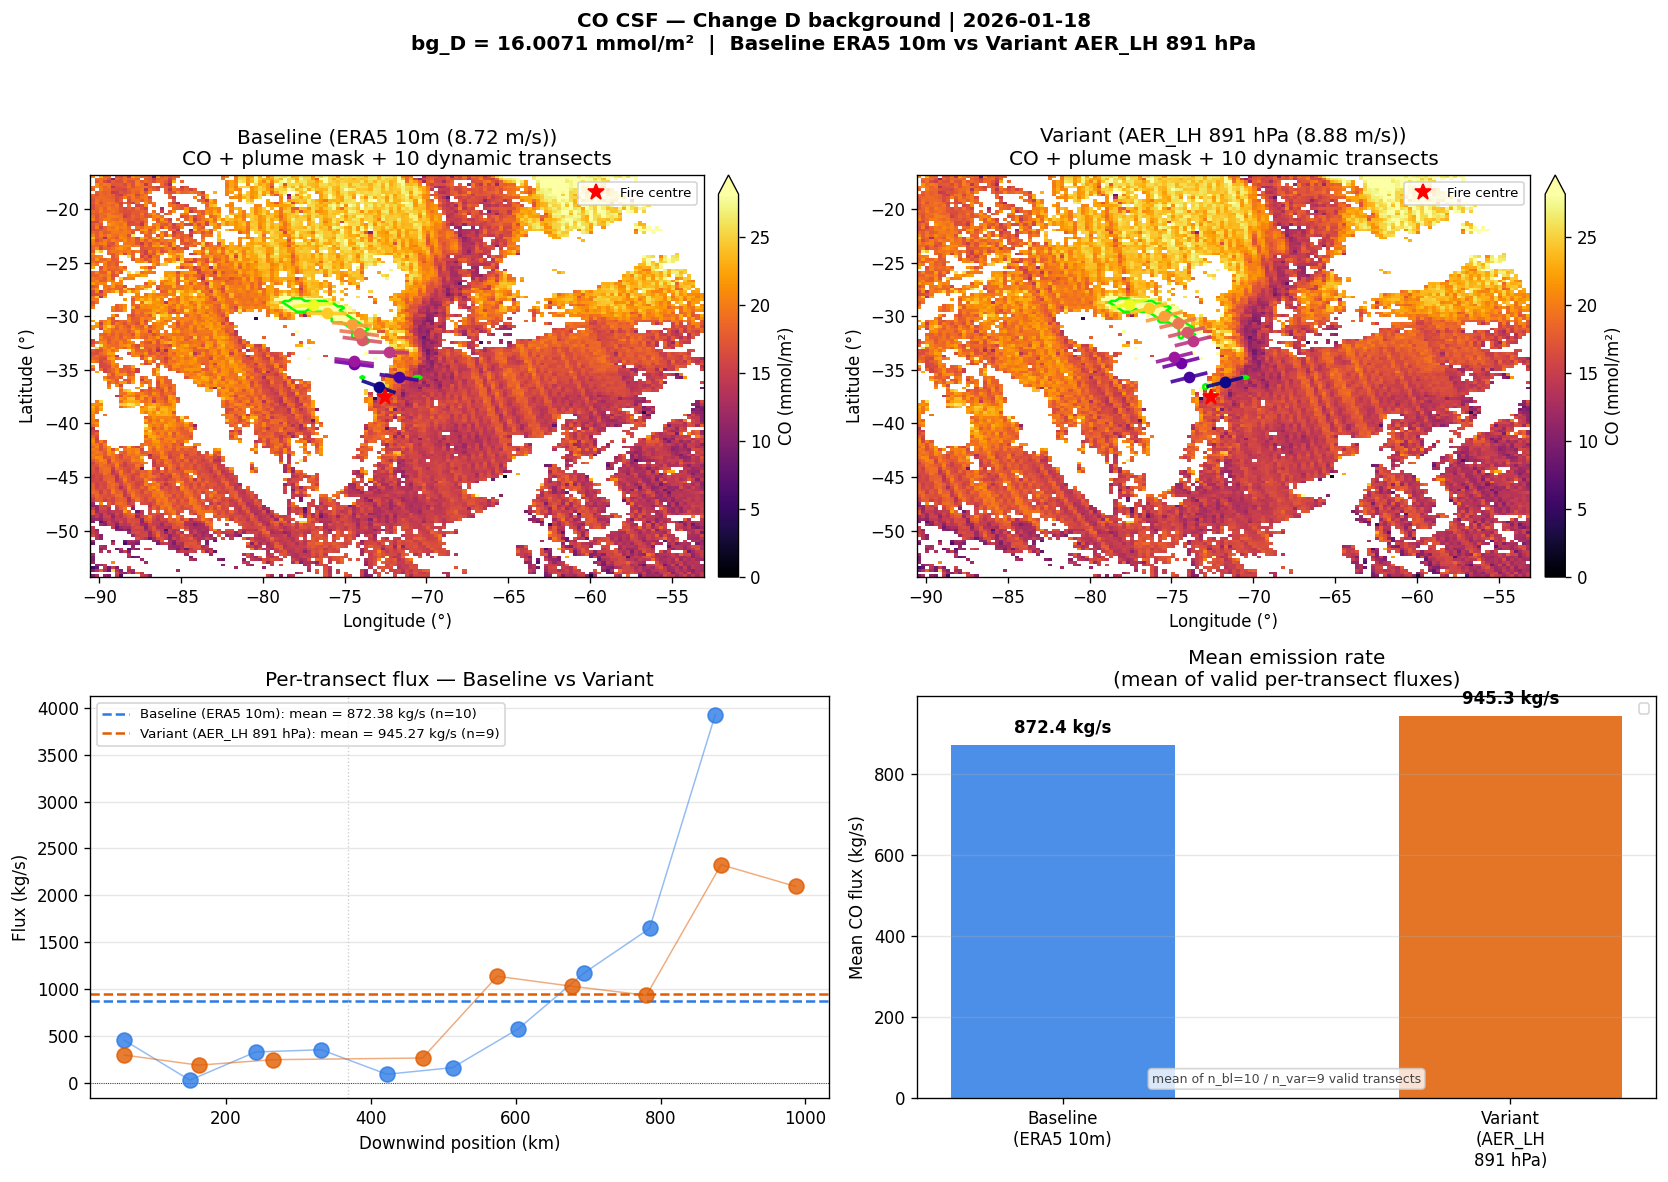

Saved: /Users/maperezc/Downloads/wildfires/outputs/co_final/0118/co_csf_diagnostic.png


In [14]:
slab_cmap = plt.cm.plasma
slab_colors = [slab_cmap(k / max(N_TRANSECTS - 1, 1)) for k in range(N_TRANSECTS)]

_r = slice(50, 200); _c = slice(50, 200)
co_mmol = np.where(np.isfinite(co), co * 1e3, np.nan)
vmax_co = float(np.nanpercentile(co_mmol[_r, _c], 98))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (label, wind_label, transects_k, t_flux_kgs_k, flux_kgs_k,
          slab_pos_k, spd_k, p_label) in enumerate([
    ("Baseline", f"ERA5 10m ({spd_sfc:.2f} m/s)",
     transects_bl, t_flux_bl_kgs, flux_bl_kgs, slab_pos_bl, spd_sfc, ""),
    ("Variant", f"AER_LH {p_alh_hpa:.0f} hPa ({spd_alh:.2f} m/s)",
     transects_var, t_flux_var_kgs, flux_var_kgs, slab_pos_var, spd_alh, ""),
]):
    # ── Row 0: CO column + AI mask + dynamic transects (unchanged) ──────────
    ax = axes[0, col]
    im = ax.pcolormesh(
        lon[_c], lat[_r], co_mmol[_r, _c],
        cmap="inferno", norm=mcolors.Normalize(0, vmax_co), shading="auto")
    if plume.any():
        ax.contour(
            lon[_c], lat[_r], plume.astype(np.float32)[_r, _c],
            levels=[0.5], colors="lime", linewidths=1.5)
    fig.colorbar(im, ax=ax, extend="max", pad=0.02, label="CO (mmol/m²)")
    for k, t in enumerate(transects_k):
        ax.plot(t.positions_lon, t.positions_lat,
                "-", color=slab_colors[k], lw=2.2, alpha=0.9)
        mid = len(t.positions_lat) // 2
        ax.plot(t.positions_lon[mid], t.positions_lat[mid],
                "o", color=slab_colors[k], ms=6, zorder=5)
    ax.plot(FIRE_LON, FIRE_LAT, "r*", ms=10, zorder=6, label="Fire centre")
    ax.legend(loc="upper right", fontsize=8)
    ax.set(xlabel="Longitude (°)", ylabel="Latitude (°)",
           title=f"{label} ({wind_label})\nCO + plume mask + {N_TRANSECTS} dynamic transects")

# ── Row 1, Col 0: Overlaid per-transect flux scatter ────────────────────────
ax2 = axes[1, 0]

for (label, t_flux_kgs_k, flux_kgs_k, slab_pos_k, line_color, marker_color) in [
    ("Baseline (ERA5 10m)",         t_flux_bl_kgs,  flux_bl_kgs,  slab_pos_bl,  "#2c7be5", "#2c7be5"),
    (f"Variant (AER_LH {p_alh_hpa:.0f} hPa)", t_flux_var_kgs, flux_var_kgs, slab_pos_var, "#e05c00", "#e05c00"),
]:
    pos_km = slab_pos_k / 1e3
    valid  = np.isfinite(t_flux_kgs_k)
    ax2.scatter(pos_km[valid], t_flux_kgs_k[valid],
                color=marker_color, s=80, zorder=4, alpha=0.8)
    ax2.plot(pos_km[valid], t_flux_kgs_k[valid],
             color=line_color, lw=0.9, alpha=0.5, zorder=3)
    for k in np.where(~valid)[0]:
        ax2.axvline(pos_km[k], color="#cccccc", lw=0.8, ls=":")
    ax2.axhline(flux_kgs_k, color=line_color, lw=1.5, ls="--",
                label=f"{label}: mean = {flux_kgs_k:.2f} kg/s (n={int(valid.sum())})")

ax2.axhline(0, color="k", lw=0.5, ls=":")
ax2.set(xlabel="Downwind position (km)", ylabel="Flux (kg/s)",
        title="Per-transect flux — Baseline vs Variant")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

# ── Row 1, Col 1: Mean emission rate bar chart (unchanged) ──────────────────
ax_bar = axes[1, 1]
labels = ["Baseline\n(ERA5 10m)", f"Variant\n(AER_LH\n{p_alh_hpa:.0f} hPa)"]
fluxes = [flux_bl_kgs, flux_var_kgs]
colors = ["#2c7be5", "#e05c00"]
bars = ax_bar.bar(labels, fluxes, color=colors, alpha=0.85, width=0.5)

bl_valid  = t_flux_bl_kgs[np.isfinite(t_flux_bl_kgs)]
var_valid = t_flux_var_kgs[np.isfinite(t_flux_var_kgs)]
for bar, val in zip(bars, fluxes):
    ax_bar.text(bar.get_x() + bar.get_width() / 2.0,
                bar.get_height() + max(fluxes) * 0.02,
                f"{val:.1f} kg/s", ha="center", va="bottom",
                fontweight="bold", fontsize=10)
ax_bar.set(ylabel="Mean CO flux (kg/s)",
           title="Mean emission rate\n(mean of valid per-transect fluxes)")
ax_bar.legend(fontsize=8)
ax_bar.grid(axis="y", alpha=0.3)
ax_bar.set_ylim(bottom=0)
ax_bar.annotate(
    f"mean of n_bl={int(np.sum(np.isfinite(t_flux_bl_kgs)))} / "
    f"n_var={int(np.sum(np.isfinite(t_flux_var_kgs)))} valid transects",
    xy=(0.5, 0.04), xycoords="axes fraction", ha="center",
    fontsize=7.5, color="#444444",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.8))

fig.suptitle(
    f"CO CSF — Change D background | {FIRE_DATE}\n"
    f"bg_D = {bg_D*1e3:.4f} mmol/m²  |  "
    f"Baseline ERA5 10m vs Variant AER_LH {p_alh_hpa:.0f} hPa",
    fontweight="bold", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT_DIR / "co_csf_diagnostic.png", bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'co_csf_diagnostic.png'}")